### Projet : Construction d'un modele d'apprentissage basées sur les donnéesdRH 

**But :**  ***Prédire le départ d'un employé***

**Approche :** 
  1. **AED**
  2. **Graphics**
  3. **Modélisation**
  4. **Interprétation**

#### 1. Importation des packages

In [4]:
# Import packages
# Pour la mnipulation des donnees
import numpy as np
import pandas as pd

# pour la visiualisation des donnees
import matplotlib.pyplot as plt

# Pour l'affichage entier des colonnes
pd.set_option('display.max_columns', None)

# Pour la modelisation
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Pour les metriaues et autres fonction utiles
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# Pour la sauvegarde..
import pickle

In [5]:
%pip install seaborn
import seaborn as sns

#### 2. Chargement des Donnees

In [6]:
df0=pd.read_csv('HR_synthese_dataset.csv')

#### 3. Exploration des données (analyse exploratoire initiale et nettoyage des données)

* Comprendre vos variables
* Nettoyer votre jeu de données (données manquantes, données redondantes, valeurs aberrantes)

##### 3.1 : Collecte des informations de base sur les données

In [7]:
# Collecter des informations de base sur les données
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [8]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


##### 3.2 : Collecte des statistiques descriptives sur le dataset

In [9]:
# Collecter les stats descriptives
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


##### 3.3 : Verification et Renom de quelques colonnes

In [10]:
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [11]:
# Renommer des colonnes
df0=df0.rename(columns={'average_montly_hours':'average_monthly_hours',
                        'Work_accident': 'work_acident',
                        'time_spend_company':'tenure',
                        'Department': 'department'})
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_acident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

##### 3. 4 : Verification des valeurs manquantes

In [12]:
# Trouver les valeurs manquantes
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_acident             0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

##### 3.5 : Verification des doublons

In [13]:
# Trouver les doublons dans le dataset
print(df0.duplicated().sum())

3008


3,008 observations contiennent des doublons. Cela represente **`20%`**  des donnees.

In [14]:
df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_acident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


Le résultat ci-dessus présente les cinq premières occurrences de lignes dupliquées dans le tableau de données. Quelle est la probabilité qu'il s'agisse d'entrées légitimes ? Autrement dit, est-il plausible que deux employés aient déclaré exactement la même réponse pour chaque colonne ?

Il serait important d'effectuer une analyse de vraisemblance en appliquant le théorème de Bayes et en multipliant les probabilités de trouver chaque valeur dans chaque colonne, mais cela ne semble pas nécessaire. 

`Avec plusieurs variables continues réparties sur 10 colonnes, il paraît très improbable que ces observations soient légitimes. L'on peut tout simplement les supprimer.`

In [15]:
# Supprimer les doublons
df0=df0.drop_duplicates()
print(df0.duplicated().sum())

0


##### 3.6 : Verification des valeurs aberantes

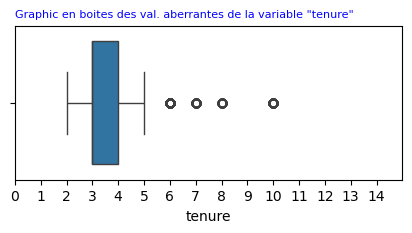

In [16]:
# Ploter les valeurs aberrantes de la colonne 'tenure'
plt.figure(figsize=(5,2))
plt.title('Graphic en boites des val. aberrantes de la variable "tenure"', 
          fontsize=8, color='blue', loc='left')
plt.xlim(0,15)
plt.xticks(range(0,15,1))
sns.boxplot(x=df0['tenure'])
plt.show()

Le diagramme en boîte ci-dessus montre la présence de valeurs aberrantes dans la variable « ancienneté ».

Il serait utile d'examiner combien de lignes du jeu de données contiennent des valeurs aberrantes dans la colonne « ancienneté ».

In [17]:
q1=df0['tenure'].quantile(0.25)
q3=df0['tenure'].quantile(0.75)
iqr=q3-q1
lim_inf=q1-1.5*iqr
lim_sup=q3+1.5*iqr
print('limite inferieure:', lim_inf)
print('limite superieure:', lim_sup)
val_aberr=df0[(df0['tenure']>lim_sup)|(df0['tenure']<lim_inf)]
print('Nombre de valeurs aberrantes:', len(val_aberr))

limite inferieure: 1.5
limite superieure: 5.5
Nombre de valeurs aberrantes: 824


****Certains types de modèles sont plus sensibles aux valeurs aberrantes que d'autres.****
`Lors de la construction du modèle, réfléchir à l'opportunité de supprimer ces valeurs aberrantes en fonction du type de modèle choisi.`

#### 4. AED (suite)

***Détermination du nombre d'employés qui ont quitté l'entreprise et le pourcentage que représente ce chiffre par rapport à l'ensemble des employés***.

In [18]:
# Trouver le nombre d'employes qui quittent vs celui qui restent
print(df0['left'].value_counts().to_frame(name='count'))
print()
# Calcul du pourcentage de ce chiffre
print((df0['left'].value_counts(normalize=True)*100).round(3).to_frame(name='count'))

      count
left       
0     10000
1      1991

       count
left        
0     83.396
1     16.604


#### 5. Visuation des donnees

****Situation des variables pertinentes et création des graphiques pour visualiser les relations entre elles dans les données****.

* Un diagramme en boîte empilé montrant la distribution des heures mensuelles moyennes pour le nombre de projets, en comparant les distributions des employés restés à celles des employés partis.

**NB :** Les diagrammes en boîte sont très utiles pour visualiser les distributions au sein des données, mais ils peuvent être trompeurs sans connaître la taille des échantillons qu'ils représentent. 

* Un histogramme empilé serait utile pour visualiser la distribution du nombre de projets pour les employés restés et ceux partis.

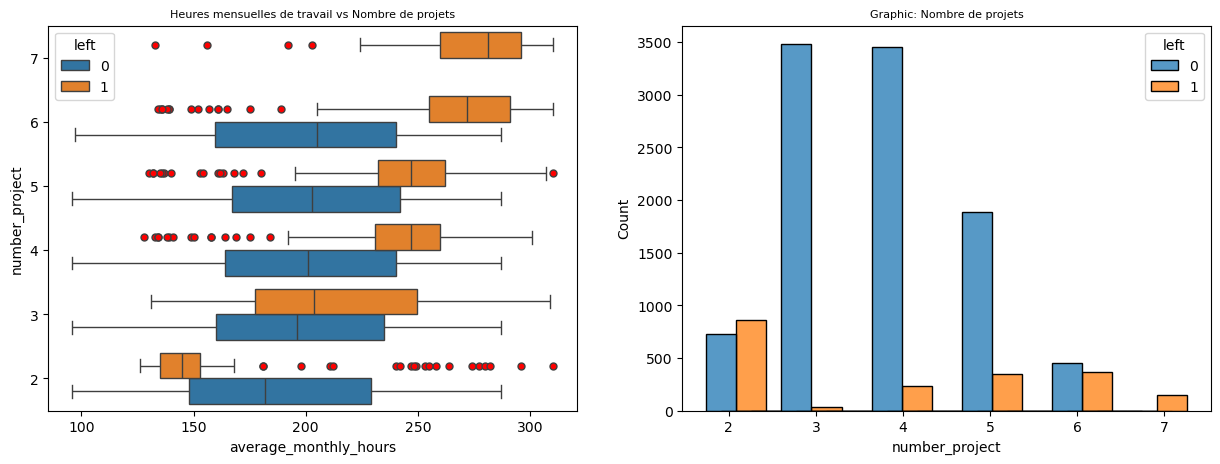

In [19]:
# Définir la figure et les axes
fig, ax = plt.subplots(1,2, figsize=(15,5))

# Créer un diagramme en boîte montrant la distribution des `average_monthly_hours` pour `number_project`, 
# en comparant les employés restés à ceux qui sont partis
sns.boxplot(data=df0, x='average_monthly_hours', y='number_project',
            hue='left', orient='h', fliersize=5,
            flierprops=dict(marker='o', markerfacecolor='red', 
            markersize=5), ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title("Heures mensuelles de travail vs Nombre de projets", fontsize=8)

# Créer un histogramme montrant la distribution de `number_project`, comparant les employés restés à ceux qui sont partis
sns.histplot(data=df0, x='number_project', hue='left', multiple='dodge', 
             shrink=4, ax=ax[1])
ax[1].set_title('Graphic: Nombre de projets', fontsize=8)

# Afficher les graphics
plt.show()

Il pourrait sembler naturel que les personnes travaillant sur plusieurs projets travaillent également plus longtemps. Cela semble se confirmer ici, car la durée moyenne de travail de chaque groupe (restés et partis) augmente avec le nombre de projets gérés. Cependant, quelques points ressortent de ce graphique.

Deux groupes d'employés ont quitté l'entreprise : (A) ceux qui travaillaient nettement moins que leurs collègues ayant le même nombre de projets, et (B) ceux qui travaillaient beaucoup plus. Parmi les employés du groupe A, il est possible qu'ils aient été licenciés. Il est également possible que ce groupe comprenne des employés ayant déjà donné leur préavis et dont le temps de travail a été réduit en raison de leur départ imminent. Quant aux employés du groupe B, il est raisonnable de supposer qu'ils ont démissionné. Ces derniers ont probablement beaucoup contribué aux projets auxquels ils ont participé ; ils en étaient peut-être même les principaux contributeurs.

Tous les employés ayant sept projets ont quitté l'entreprise, et l'écart interquartile entre ce groupe et ceux ayant six projets était d'environ 255 à 295 heures par mois, soit bien plus que pour tout autre groupe.

Le nombre optimal de projets sur lesquels travaillent les employés semble se situer entre 3 et 4. Le ratio départs/retraite est très faible pour ces groupes.

En supposant une semaine de travail de 40 heures et deux semaines de congés par an, le nombre moyen d'heures travaillées par mois pour les employés travaillant du lundi au vendredi est de `50 semaines * 40 heures par semaine / 12 mois = 166,67` heures par mois. Cela signifie que, mis à part les employés qui travaillaient sur deux projets, tous les autres groupes – même ceux qui sont restés dans l'entreprise – ont travaillé beaucoup plus d'heures. Il semblerait donc que les employés soient surchargés de travail.

Dans un second temps, il serait possible de vérifier si tous les employés ayant sept projets ont quitté l'entreprise.

In [20]:
# Obtenir le nombre d'employees de maintien/départ des employés ayant 7 projets
df0[df0['number_project']==7]['left'].value_counts()

left
1    145
Name: count, dtype: int64

Cela confirme que tous les employés ayant sept projets en cours ont quitté l'entreprise.

* Ensuite, l'on peut examiner le nombre moyen d'heures travaillées par mois en fonction du niveau de satisfaction.

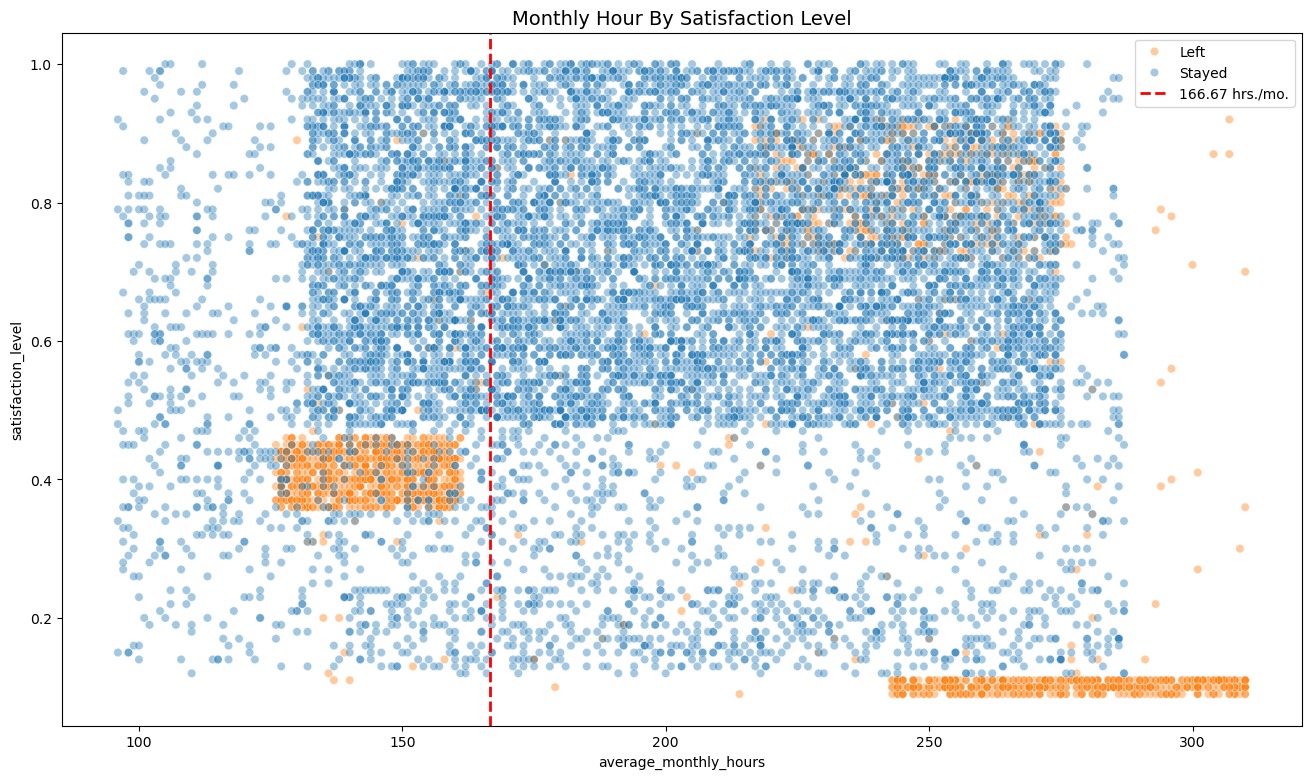

In [21]:
# Créer un nuage de points représentant `average_monthly_hours` en fonction de `satisfaction_level`, 
# en comparant les employés restés à ceux qui sont partis.
df0['status']=df0['left'].map({0:'Stayed', 1:'Left'})
palette= {
    'Stayed':'#1f77b4',
    'Left':'#ff7f0e'
}
# Definir la figure
plt.figure(figsize=(16,9))

# Construre un nuage de points
ax=sns.scatterplot(data=df0,x='average_monthly_hours',
                            y='satisfaction_level',
                            hue='status',
                            palette=palette,
                            alpha=0.4
                  )
# Tracer une ligne verticale dont la valeur est de 166,67 heures
ln=plt.axvline(x=166.67,
               color='red', 
               linestyle='--',
               linewidth=2
              )
handles, labels=ax.get_legend_handles_labels()
handles.append(ln)
labels.append('166.67 hrs./mo.')
plt.legend(handles=handles, labels=labels)
plt.title('Monthly Hour By Satisfaction Level', fontsize='14')
plt.show()

Le nuage de points ci-dessus montre qu'un groupe important d'employés travaillait environ 240 à 315 heures par mois. Cela représente plus de 75 heures par semaine pendant une année entière. Il est probable que leur niveau de satisfaction, proche de zéro, soit lié à ce volume horaire.

Le graphique montre également un autre groupe d'employés ayant quitté l'entreprise, ceux qui avaient des horaires de travail plus classiques. Malgré cela, leur satisfaction n'était que d'environ 0,4. Il est difficile de spéculer sur les raisons de leur départ. Il est possible qu'ils se soient sentis obligés de travailler davantage, étant donné que beaucoup de leurs collègues travaillaient plus. Cette pression aurait pu faire baisser leur niveau de satisfaction.

Enfin, un groupe travaillait environ 210 à 280 heures par mois, avec des niveaux de satisfaction compris entre 0,7 et 0,9.

On remarque la forme inhabituelle de ces distributions. Cela indique une manipulation des données ou l'utilisation de données synthétiques.

****Pour la prochaine visualisation, il pourrait être intéressant de représenter les niveaux de satisfaction en fonction de l'ancienneté.****

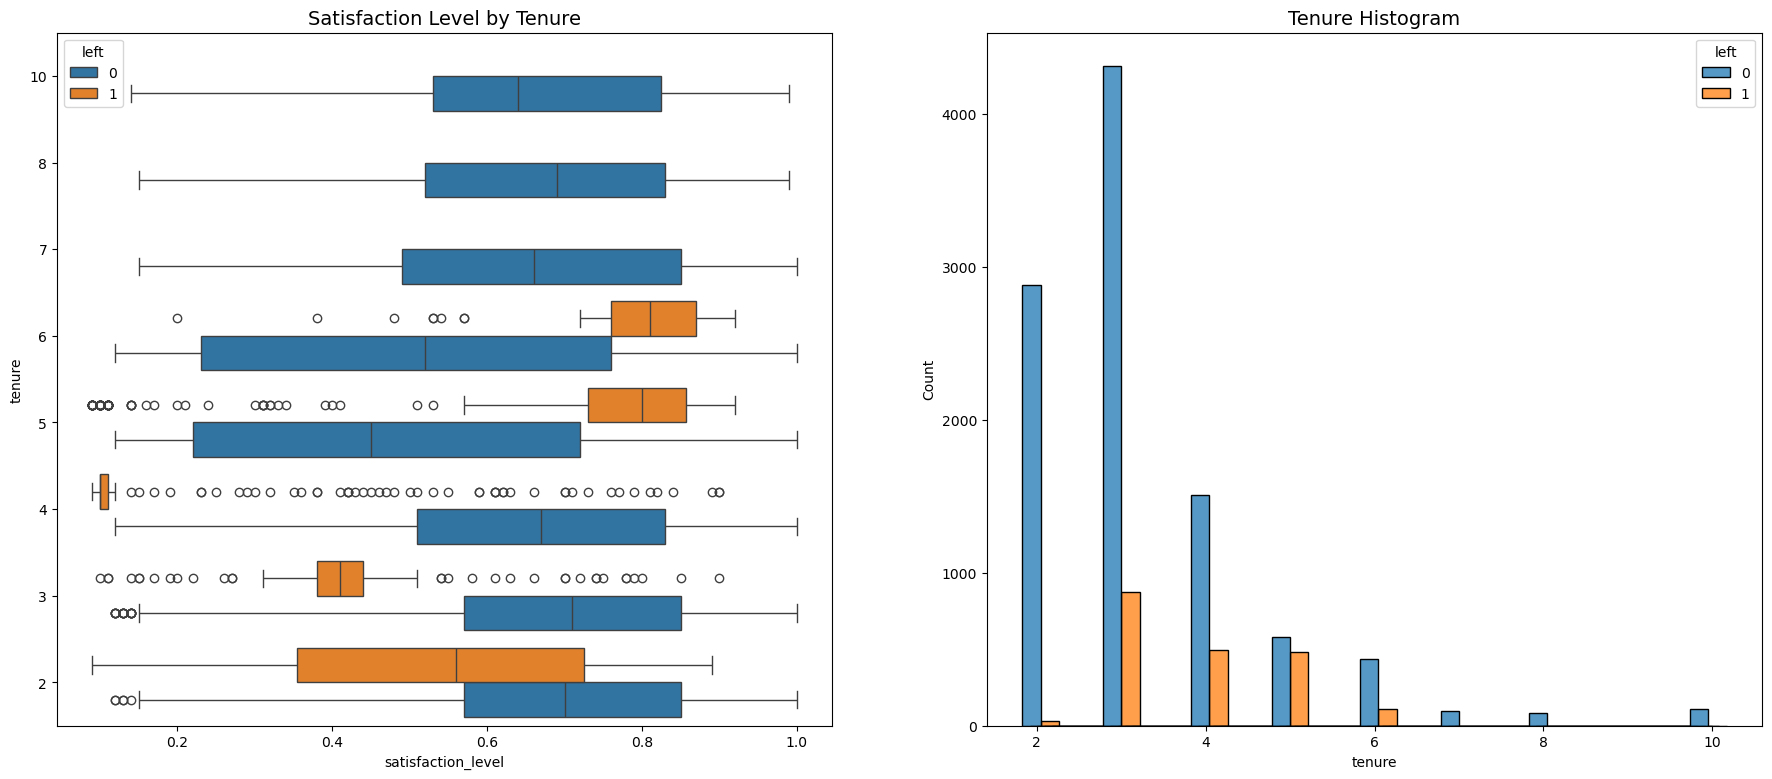

In [22]:
# Definir la figure et les axes
fig, ax = plt.subplots(1,2, figsize=(22,9))
# Tracer un diagramme en boites montrant le niveau de satisfaction vs l'anciennete
sns.boxplot(data=df0, 
            x='satisfaction_level',
            y='tenure',
            hue='left',
            orient='h',
            ax=ax[0]
           )
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction Level by Tenure', fontsize ='14')

# Tracer un histogramme de l'anciennete comparant les departs et ceux qui restent
sns.histplot(data=df0,
             x='tenure',
             hue='left',
             multiple='dodge',
             shrink=5,
             ax=ax[1]
            )
ax[1].set_title('Tenure Histogram', fontsize = '14')
plt.show()

            

Ce graphique permet de tirer plusieurs observations.

Les employés ayant quitté l'entreprise se répartissent en deux grandes catégories : les employés insatisfaits ayant une ancienneté plus courte et les employés très satisfaits ayant une ancienneté moyenne.

Les employés ayant quatre ans d'ancienneté et ayant quitté l'entreprise semblent présenter un niveau de satisfaction anormalement bas. Il serait pertinent d'étudier, si possible, les changements de politique interne susceptibles d'avoir affecté spécifiquement les employés ayant quatre ans d'ancienneté.

Les employés les plus anciens n'ont pas quitté l'entreprise. Leur niveau de satisfaction est comparable à celui des employés plus récents restés.

L'histogramme montre que les employés ayant une longue ancienneté sont relativement peu nombreux. Il est possible qu'il s'agisse des employés les plus gradés et les mieux rémunérés.

***Approfondir l'analyse des données:*** calcul de la moyenne et de la médiane des scores de satisfaction des employés ayant quitté l'entreprise et de ceux qui y sont restés.

In [23]:
# Calcul de la moyenne et de la mediane des scores de satisfaction
df0.groupby(['left'])['satisfaction_level'].agg(['mean', 'median'])

,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


Comme prévu, les scores de satisfaction moyens et médians des employés ayant quitté l'entreprise sont inférieurs à ceux des employés restés. Il est intéressant de noter que, parmi ces derniers, le score de satisfaction moyen semble légèrement inférieur au score médian. Cela suggère que la satisfaction des employés restés pourrait être biaisée vers la baisse.

****Examiner ensuite les niveaux de salaire en fonction de l'ancienneté.****

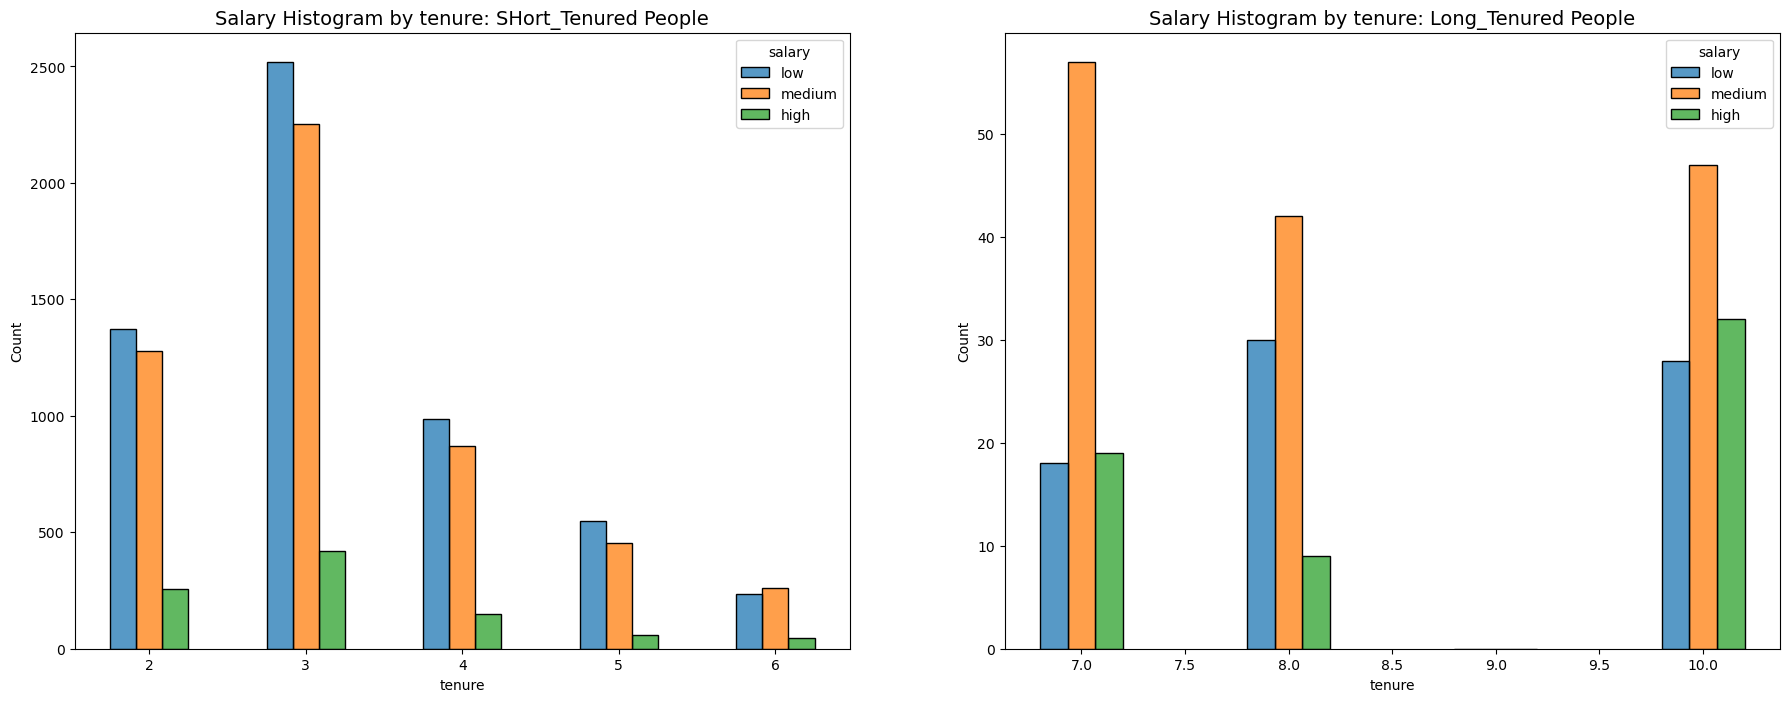

In [24]:
# Définir les employés à courte ancienneté
tenure_short=df0[df0['tenure']<7]
# Définir les employés à longue ancienneté
tenure_long=df0[df0['tenure']>6]

# Definir la figure te les axes
fig, ax=plt.subplots(1,2, figsize=(22,8))
# Tracer un histogramme des salaries non anciens
sns.histplot(data=tenure_short,
             x='tenure',
             hue='salary',
             discrete=True,
             hue_order=['low', 'medium', 'high'],
             multiple='dodge',
             shrink=.5,
             ax=ax[0]
            )
ax[0].set_title('Salary Histogram by tenure: SHort_Tenured People', fontsize=14)

# Tracer un histogramme des salaries anciens
sns.histplot(data=tenure_long,
             x='tenure',
             hue='salary',
             discrete=True,
             hue_order=['low','medium', 'high'],
             multiple='dodge',
             shrink=.4,
             ax=ax[1]
            )
ax[1].set_title('Salary Histogram by tenure: Long_Tenured People', fontsize=14)

# Afficher les graphics
plt.show()
             


Les graphiques ci-dessus montrent que les employés ayant une longue ancienneté ne sont pas surreprésentés parmi les employés les mieux rémunérés.

Ensuite, l'on pourrait examiner s'il existe une corrélation entre le nombre d'heures travaillées et l'obtention de scores d'évaluation élevés.
Créer un nuage de points représentant le nombre moyen d'heures mensuelles travaillées en fonction de la dernière évaluation.

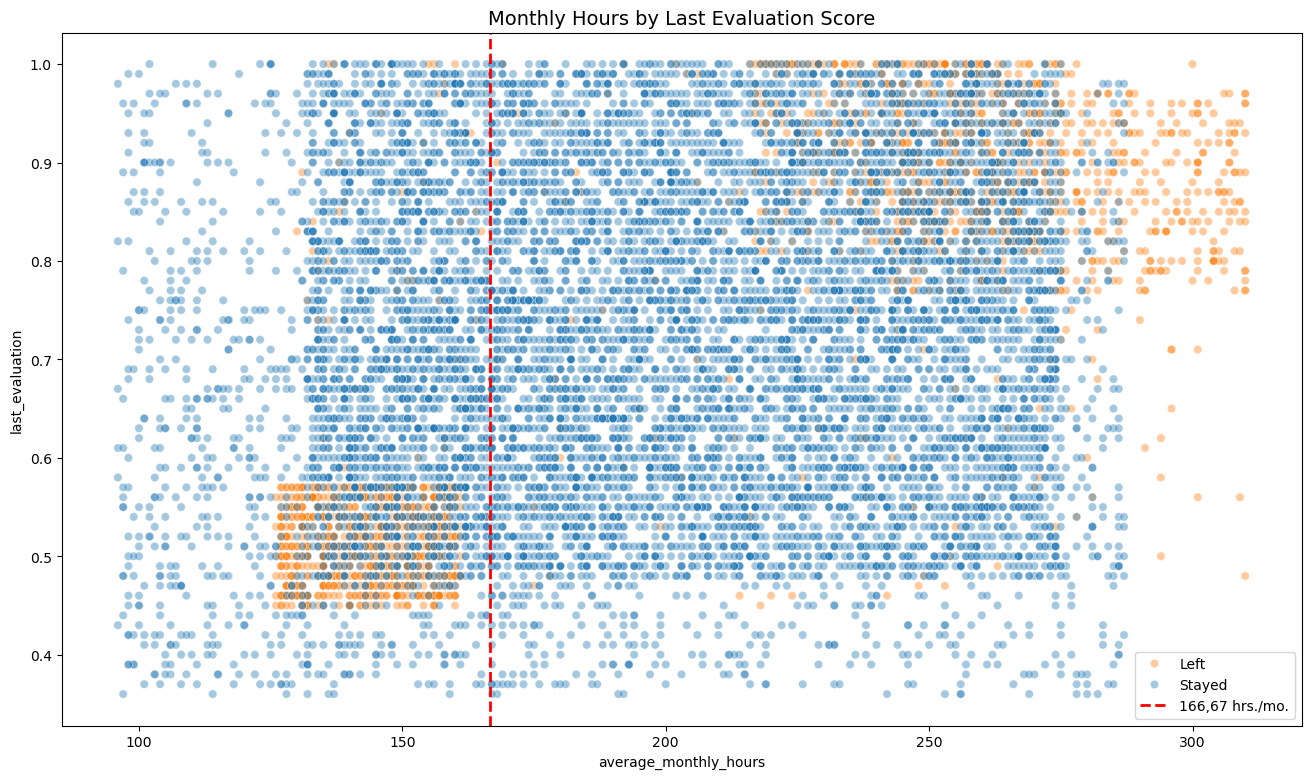

In [25]:
# Definir la figure
plt.figure(figsize=(16,9))
# Tracer le nuage de points
ax=sns.scatterplot(data=df0,
                x='average_monthly_hours',
                y='last_evaluation',
                hue='status',
                palette=palette,
                alpha=0.4
               )
# Retracer la ligne verticale d'abscisse 166,67 heures
ln=plt.axvline(x=166.67,
            color='red',
            linestyle='--',
            linewidth=2
           )
handles, labels=ax.get_legend_handles_labels()
handles.append(ln)
labels.append('166,67 hrs./mo.')
plt.legend(handles=handles, labels=labels)
plt.title('Monthly Hours by Last Evaluation Score', fontsize=14)
plt.show()


Les observations suivantes peuvent être tirées du nuage de points ci-dessus :

Le nuage de points indique deux groupes d'employés ayant quitté l'entreprise : les employés surchargés de travail mais très performants, et ceux qui travaillaient légèrement en dessous de la moyenne mensuelle nominale de 166,67 heures et qui ont obtenu des scores d'évaluation plus faibles.

Il semble exister une corrélation entre le nombre d'heures travaillées et le score d'évaluation.

Le pourcentage d'employés dans le quadrant supérieur gauche de ce graphique est faible ; cependant, travailler de longues heures ne garantit pas un bon score d'évaluation.

La plupart des employés de cette entreprise travaillent bien plus de 167 heures par mois.

Il serait ensuite pertinent d'examiner si les employés ayant effectué de très longues heures ont bénéficié d'une promotion au cours des cinq dernières années.

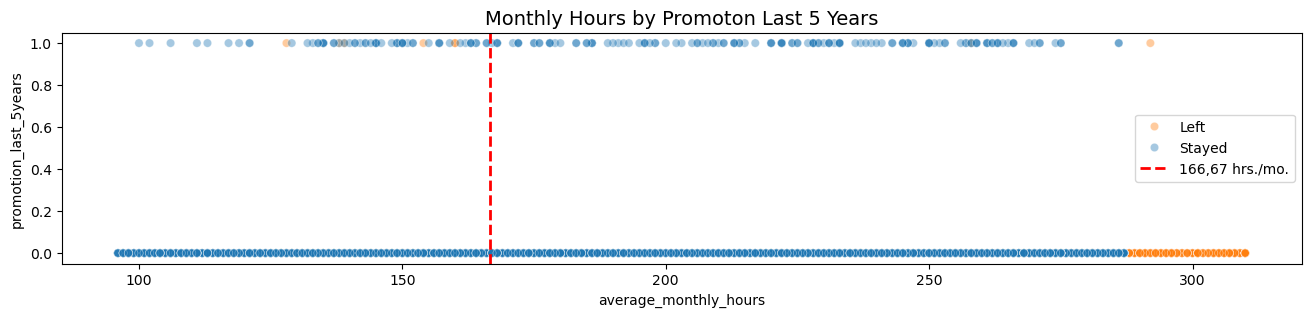

In [26]:

# Créer un graphique pour examiner la relation entre `average_monthly_hours` et `promotion_last_5years`
plt.figure(figsize=(16,3))
ax=sns.scatterplot(data=df0,
                   x='average_monthly_hours',
                   y='promotion_last_5years',
                   hue='status',
                   palette=palette,
                   alpha=0.4
                  )
ln=plt.axvline(x=166.67,
               color='red',
               linestyle='--',
               linewidth=2
              )
handles, labels=ax.get_legend_handles_labels()
handles.append(ln)
labels.append('166,67 hrs./mo.')
plt.legend(handles=handles, labels=labels)
plt.title('Monthly Hours by Promoton Last 5 Years', fontsize=14)
plt.show()
           

Le graphique ci-dessus montre ce qui suit :

* très peu d'employés promus au cours des cinq dernières années ont quitté l'entreprise ;

* très peu d'employés ayant effectué le plus d'heures ont été promus ;

* tous les employés ayant quitté l'entreprise effectuaient le plus d'heures.

****Examiner la répartition des employés ayant quitté l'entreprise par service.****

In [27]:
# Afficher le nombre d'employes par service/departement
df0['department'].value_counts()

department
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

****Créer un histogramme empilé pour comparer la répartition par département des employés ayant quitté l'entreprise à celle des employés restés.****

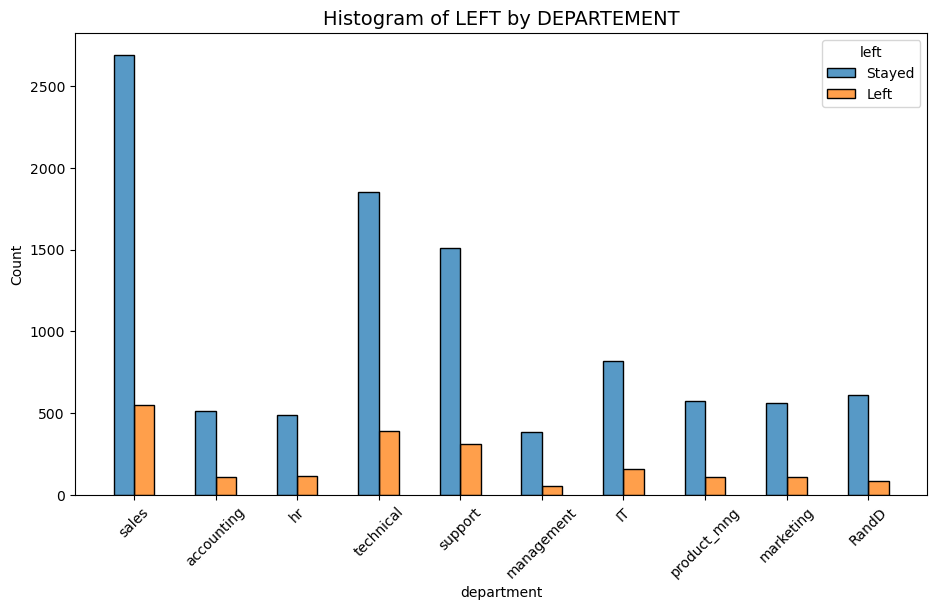

In [28]:
# Convertir et appliquer des valeurs 'Stayed' et 'Left' aux codes 0 et 1
df0['left']=df0['left'].map({0:'Stayed', 1:'Left'})
# Definir la figure
plt.figure(figsize=(11,6))

# Tracer l'histogramme empilee
sns.histplot(data=df0,
             x='department',
             discrete=True,
             hue='left',
             hue_order=['Stayed', 'Left'],
             multiple='dodge',
             shrink=.5
            )
plt.xticks(rotation=45)
plt.title("Histogram of LEFT by DEPARTEMENT", fontsize=14)
plt.show()


Il ne semble pas y avoir de différence significative entre les proportions d'employés ayant quitté l'entreprise et ceux qui y sont restés, selon les services.

****Enfin, l'on peut rechercher d'éventuelles corrélations fortes entre les variables présentes dans les données.****

***Carte thermique de corrélation***

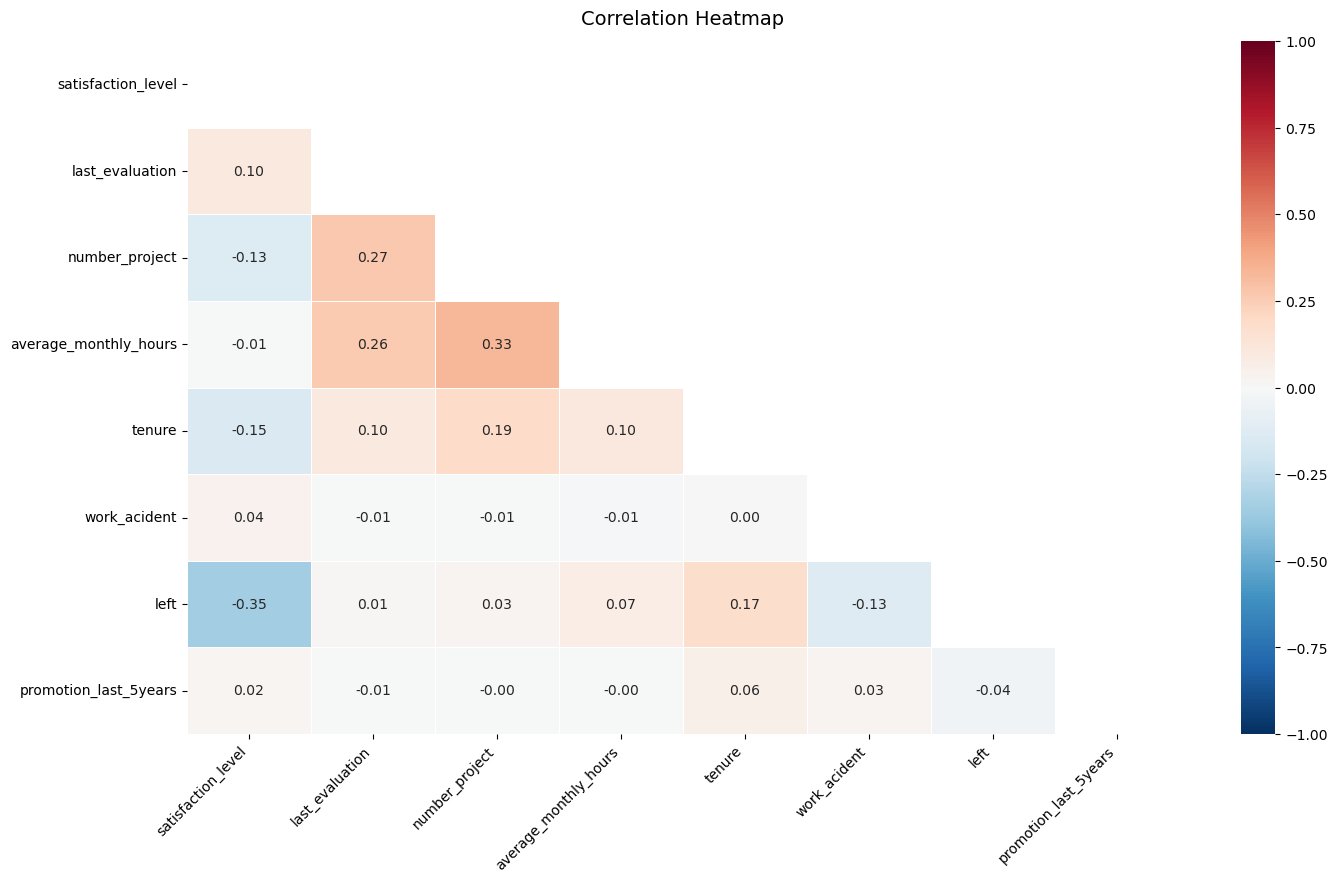

In [29]:
# Reconstitution de la colonne 'left'
df0['left']=df0['status'].astype(str).str.strip().str.lower().map(
    {'left':1,
     'stayed':0
    })
corr=df0.select_dtypes(include='number').corr()  # Pour n'inclure que les donnees numeriques: heatmap ne prend pas en charge les non numeriques
mask=np.triu(np.ones_like(corr, dtype=bool))

# Definir la figure
plt.figure(figsize=(16,9))
# Tracer la carte thermique
sns.heatmap(corr,
            mask=mask,
            vmin=-1, vmax=1,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            linewidths=0.5
            )
plt.xticks(rotation=45, ha='right')
plt.title('Correlation Heatmap', fontsize=14, pad=12)
plt.show()       

La carte thermique des corrélations confirme que le nombre de projets, le nombre d'heures mensuelles et les scores d'évaluation présentent tous une corrélation positive, tandis que le départ d'un employé est inversement corrélé à son niveau de satisfaction.

**Constatations:**

Il semblerait que les départs soient dus à une mauvaise gestion. Ces départs sont liés à des horaires de travail plus longs, à une charge de travail importante et, de manière générale, à une satisfaction moindre. Travailler de longues heures sans obtenir de promotions ni de bonnes évaluations peut être décourageant. Un nombre important d'employés de cette entreprise souffrent probablement d'épuisement professionnel. Il apparaît également que les employés ayant plus de six ans d'ancienneté ont tendance à rester dans l'entreprise.

#### 6. Modelisation

1. Vérifier les hypothèses du modèle
2. Construire le modèle
3. Déterminer les modèles les plus appropriés
4. Évaluer les résultats du modèle pour déterminer sa qualité d'ajustement aux données

### **Rappel des hypothèses du modèle**

***Hypothèses du modèle de régression logistique***

* Variable dépendante catégorielle
* Indépendance des observations
* Absence de multicolinéarité importante entre les variables predictives
* Absence de valeurs aberrantes extrêmes
* Relation linéaire entre chaque variable X et le logit de la variable dépendante
* Taille de l'échantillon suffisamment grande

## **Construction du modèle, Résultats et Evaluation**

- Ajuster un modèle qui prédit la variable de résultat à l'aide d'au moins deux variables indépendantes.
- Vérifier les hypothèses du modèle.
- Évaluer le modèle.

**Identification du type de la variable resultat (dependante).**

L'objectif étant de prédire si un employé quitte l'entreprise, alors ceci correspond à une variable de résultat catégorielle. Cette tâche implique donc une classification. Plus précisément, il s'agit d'une classification binaire, puisque la variable de résultat « `left` » prend la valeur 1 (l'employé a quitté l'entreprise) ou 0 (l'employé n'a pas quitté l'entreprise).

**Identification des modèles les plus appropriés pour cette tâche.**

Puisque la variable à prédire (le départ d'un employé de l'entreprise) est catégorielle, l'on peut construire un modèle de régression logistique ou un modèle d'apprentissage automatique basé sur un arbre de décision.

****<u>L'on peut peut essayer chacune des approches l'une apres l'autre et comparer leur performance</u>****

### **Approche A:**  ***Modèle de régression logistique***

**NB:** La régression logistique binomiale convient à cette tâche car elle repose sur une classification binaire.

Avant de segmenter les données, l'on doit encoder toutes les variables non numériques. Ici il y en a deux : `department` et `salary`.

La variable `department` est catégorielle, ce qui signifie qu'on peut l'utiliser comme variable indicatrice pour la modélisation.

La variable `salary` est également catégorielle, mais ordinal. Les catégories étant hiérarchisées, il est préférable de ne pas utiliser de variable indicatrice pour cette colonne, mais plutôt de convertir ses niveaux en nombres (de 0 à 2).

In [30]:
# Encodage des variables non numerics
df_enc=df0.copy()      #     Copie de la dataframe
df_enc['salary_clean']=(
    df_enc['salary'].astype(str)
    .str.strip()
    .str.lower()
)
mapping= {'low':0, 'medium':1, 'high':2}
df_enc['salary']=df_enc['salary_clean'].map(mapping)
# Verification
if df_enc['salary'].isna().any():
    print('Valeurs salary inconnues:', df_enc['salary_clean'].unique())

# Encodage des colonnes categrielles uniquement
cat_cols=df_enc.select_dtypes(include='object').columns
# Exclure d'autres colonnes
cat_cols=cat_cols.drop(['salary_clean'], errors='ignore')

df_enc=pd.get_dummies(df_enc, dtype=int, columns=cat_cols, drop_first=False)
# Affiche la nouvelle dataframe
df_enc.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_acident,left,promotion_last_5years,salary,salary_clean,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,status_Left,status_Stayed
0,0.38,0.53,2,157,3,0,1,0,0,low,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,1,medium,0,0,0,0,0,0,0,1,0,0,1,0
2,0.11,0.88,7,272,4,0,1,0,1,medium,0,0,0,0,0,0,0,1,0,0,1,0
3,0.72,0.87,5,223,5,0,1,0,0,low,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,low,0,0,0,0,0,0,0,1,0,0,1,0


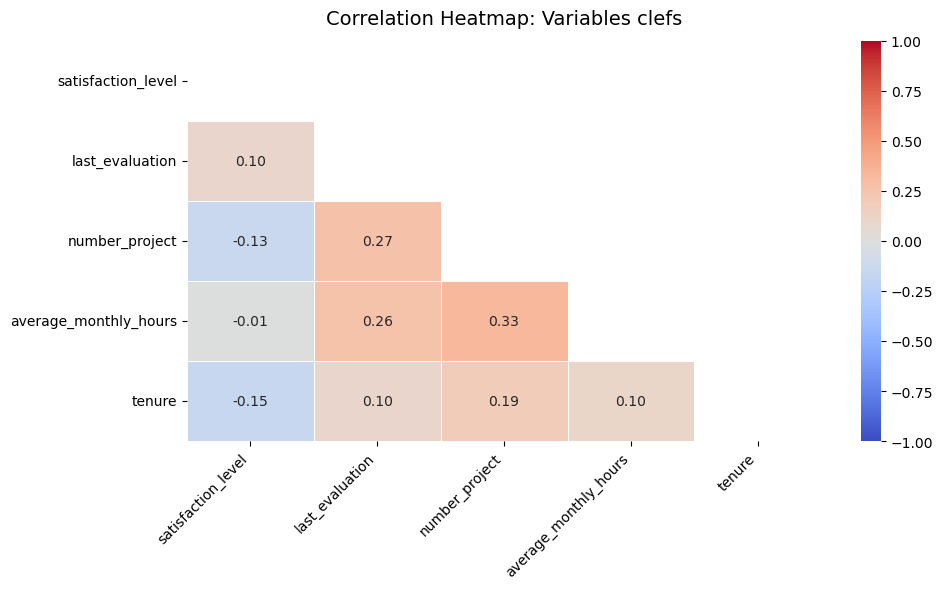

In [31]:
corr=df_enc[['satisfaction_level',
            'last_evaluation',
            'number_project',
            'average_monthly_hours',
            'tenure']].corr()
mask=np.triu(np.ones_like(corr, dtype=bool))   #  Eviter la redondance (doublons de carrees)
# Definir la figure
plt.figure(figsize=(10,6)) 

sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1, vmax=1,
            linewidths=0.5,
            cbar_kws={'shrink':1}
           )
plt.xticks(rotation=45, ha='right')
plt.title('Correlation Heatmap: Variables clefs', fontsize=14, pad=12)
plt.tight_layout()

plt.show()
          

* ****Créer un graphique à barres empilées pour visualiser le nombre d'employés par département, en comparant ceux qui sont partis à ceux qui sont restés.****

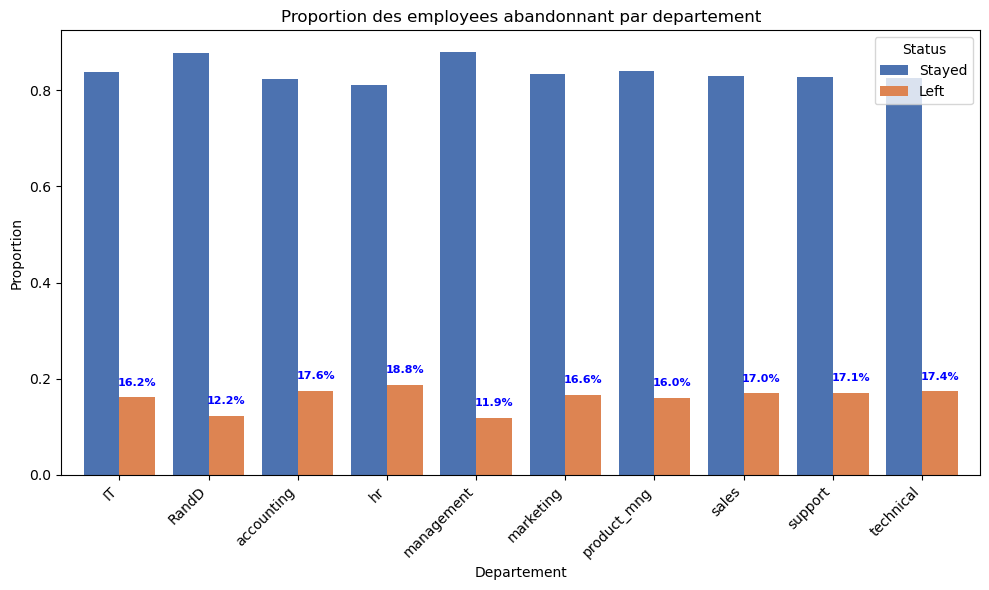

In [32]:
df_tbl=pd.crosstab(df0['department'], df0['left'], normalize='index')
df_tbl.columns=['Stayed', 'Left']
ax=df_tbl.plot(kind='bar',
            figsize=(10,6),
               width=0.8,
            color=['#4C72B0', '#DD8452']
           )
# afficher seulement le % de Left en haut
for i, val in enumerate(df_tbl['Left']):
    ax.text(i+0.2,
            val+0.02,  # légèrement au-dessus de la barre
            f"{val*100:.1f}%",
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold',
            color='blue')
    
plt.title('Proportion des employees abandonnant par departement')
plt.xlabel('Departement')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')

plt.tight_layout()
plt.show()


Étant donné que la régression logistique est très sensible aux valeurs aberrantes, il serait judicieux à ce stade de supprimer les valeurs aberrantes de la colonne « `tenure`» qui ont été identifiées précédemment.

In [33]:
# Select rows without outliers in `tenure` and save resulting dataframe in a new variable
df_logreg = df_enc[(df_enc['tenure'] >=lim_inf) & (df_enc['tenure'] <=lim_sup)]

# Display first few rows of new dataframe
df_logreg.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_acident,left,promotion_last_5years,salary,salary_clean,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,status_Left,status_Stayed
0,0.38,0.53,2,157,3,0,1,0,0,low,0,0,0,0,0,0,0,1,0,0,1,0
2,0.11,0.88,7,272,4,0,1,0,1,medium,0,0,0,0,0,0,0,1,0,0,1,0
3,0.72,0.87,5,223,5,0,1,0,0,low,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,low,0,0,0,0,0,0,0,1,0,0,1,0
5,0.41,0.50,2,153,3,0,1,0,0,low,0,0,0,0,0,0,0,1,0,0,1,0


**Isolez la variable de résultat, c'est-à-dire la variable que vous souhaitez que votre modèle prédise.**

In [34]:
# Isoler la variable 'resultat'
y=df_logreg['left']
# Affichage de la variable 'reultat'
y.head()

0    1
2    1
3    1
4    1
5    1
Name: left, dtype: int64

* Sélection des caractéristiques utiles au modèle.
* Quelles variables aideront au mieux à prédire la variable de résultat: **`left`**

In [35]:
# Selection des variables par la suppression de la variable resultat
X=df_logreg.drop(['left', 'salary_clean','status_Left', 'status_Stayed'], axis=1)
# Afficahe des variables predictives
X.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_acident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,0,0,1,0,0
5,0.41,0.50,2,153,3,0,0,0,0,0,0,0,0,0,0,1,0,0


* Division des données en un ensemble d'entraînement et un ensemble de test.
* Ne pas oublier de stratifier les données en fonction des valeurs de y, car les classes sont déséquilibrées.

In [36]:
# Diviser les donnees en donnees d'entrainement et de test
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

Construire un modèle de régression logistique et l'ajuster à l'ensemble de données d'entraînement.

In [37]:
# Construire un modèle de régression logistique et l'ajuster à l'ensemble de données d'entraînement.
model=make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=500, random_state=42)
)
model.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


**Test du modèle de régression logistique:** utiliser le modèle pour effectuer des prédictions sur l’ensemble de test.

In [38]:
# Utiliser le modèle de régression logistique pour obtenir des prédictions sur l'ensemble de test.
y_pred=model.predict(X_test)

**Création d'une matrice de confusion pour visualiser les résultats du modèle de régression logistique.**

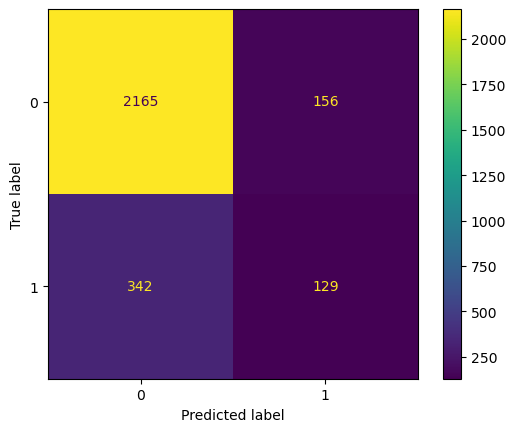

In [39]:
# Calcul des valeurs de la matrice de confusion
log_cm=confusion_matrix(y_test, y_pred, labels=model.named_steps['logisticregression'].classes_)

# Créer un graphic de la matrice de confusion
log_gr=ConfusionMatrixDisplay(confusion_matrix=log_cm,
                             display_labels=model.named_steps['logisticregression'].classes_)

# Graphique de la matrice de confusion
log_gr.plot(values_format='d')

# Afficher le graphic
plt.show()


* Le quadrant supérieur gauche affiche le nombre de vrais négatifs.
* Le quadrant supérieur droit affiche le nombre de faux positifs.
* Le quadrant inférieur gauche affiche le nombre de faux négatifs.
* Le quadrant inférieur droit affiche le nombre de vrais positifs.

Vrais négatifs : Nombre de personnes restées dans l’entreprise, correctement prédites par le modèle.

Faux positifs : Nombre de personnes restées dans l’entreprise, incorrectement prédites comme étant parties par le modèle.

Faux négatifs : Nombre de personnes ayant quitté l’entreprise, incorrectement prédites comme étant parties par le modèle.

Vrais positifs : Nombre de personnes ayant quitté l’entreprise, correctement prédites comme étant parties par le modèle.

Un modèle parfait produirait uniquement des vrais négatifs et des vrais positifs, sans aucun faux négatif ni faux positif.

Créer un rapport de classification incluant la précision, le rappel, le score F1 et l'exactitude pour évaluer les performances du modèle de régression logistique.

**Vérification de l'équilibre des classes dans les données.** Autrement dit, vérifier le nombre de valeurs dans la colonne `left`. S'agissant d'une tâche de classification binaire, l'équilibre des classes influence l'interprétation des indicateurs d'exactitude.

In [40]:
df_logreg['left'].value_counts(normalize=True)

left
0    0.831468
1    0.168532
Name: proportion, dtype: float64

La répartition est d'environ 83 % - 17 %. Les données ne sont donc pas parfaitement équilibrées, mais le déséquilibre est acceptable. En cas de déséquilibre plus important, un rééchantillonnage pourrait être envisagé. Dans ce cas, vous pouvez utiliser ces données sans modifier la répartition des classes et poursuivre l'évaluation du modèle.

In [41]:
# Créer un rapport de classification pour le modèle de régression logistique
status_names=['Would not leave', 'Would leave']
print(classification_report(y_test, y_pred, target_names=status_names))

                 precision    recall  f1-score   support

Would not leave       0.86      0.93      0.90      2321
    Would leave       0.45      0.27      0.34       471

       accuracy                           0.82      2792
      macro avg       0.66      0.60      0.62      2792
   weighted avg       0.79      0.82      0.80      2792



Le rapport de classification ci-dessus indique que le modèle de régression logistique a atteint une précision de 79 %, un rappel de 82 %, un score F1 de 80 % (moyennes pondérées) et une exactitude de 82 %. 
* Cependant, si l'objectif principal est de prédire les départs des employés, les scores sont nettement inférieurs.

### **Approche B:**  ***Modèle Arbre***

Cette approche couvre la mise en œuvre des arbres de décision et des forêts aléatoires.

In [42]:
# Isoler la variable dependante 'y'
y=df_enc['left']
# Affichage des donnees de la variable
y.head()

0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64

In [43]:
# Selection des variables par la suppression de la variable resultat
X=df_enc.drop(['left', 'salary_clean','status_Left', 'status_Stayed'], axis=1)

# Affichage des donnees
X.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_acident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,0,1,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,0,0,1,0,0


***Division des données en ensemble d'entraînement, de validation et de test.***

In [44]:
# Diviser les data...
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

##### Arbre de décision

Construire un modèle d'arbre de décision et mettre en place une recherche par grille à validation croisée pour rechercher de manière exhaustive les meilleurs paramètres du modèle.

In [45]:
# Instantiation du model
tree=DecisionTreeClassifier(random_state=0)
# Attribuer un dictionnaire d'hyperparamètres à parcourir
cv_params={'max_depth':[4,6,8,None],
           'min_samples_leaf':[1,2,5],
           'min_samples_split':[2,4,6]
          }
# Attribuer un dictionnaire de métriques de notation à capturer
scoring={
    'accuracy': 'accuracy',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}
# Instancier GridSearch
tree1=GridSearchCV(
    tree,
    cv_params,
    scoring=scoring,
    cv=4,
    refit='roc_auc'
)


In [46]:
# Ajuster le modèle d'arbre de décision aux données d'entraînement.
tree1.fit(X_train, y_train)

,estimator,DecisionTreeC...andom_state=0)
,param_grid,"{'max_depth': [4, 6, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,"{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,None
,refit,'roc_auc'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


***Identifier les valeurs optimales des paramètres de l'arbre de décision.***

In [47]:
tree1.best_params_

{'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}

***Identifier le meilleur score AUC obtenu par le modèle d'arbre de décision sur l'ensemble d'entraînement.***

In [48]:
print(tree1.best_score_)

0.969819392792457


Il s'agit d'un excellent score AUC, ce qui indique que ce modèle prédit très bien les départs d'employés.

Ensuite, l'on peut écrire une fonction qui va permettre d'extraire tous les scores de la recherche par grille.

In [49]:
def make_results(model_name:str, model_object, metric:str):
    
    # Récupérez tous les résultats de la Cross Validation (CV) et placez-les dans un df: cv_results
    cv_results=pd.DataFrame(model_object.cv_results_)
    
    # Isoler la ligne du dataframe avec le score max(metric)
    best_estimator_results=cv_results[f'mean_test_{metric}'].idxmax()

    # Recuperer la ligne correspondante au max
    row_max=cv_results.loc[best_estimator_results]
    
   # Construire le dataframe final pour stocker les resultats
    table=pd.DataFrame({'model': [model_name],
                        'precision':[row_max['mean_test_precision']],
                        'recall':[row_max['mean_test_recall']],
                        'f1':[row_max['mean_test_f1']],
                        'accuracy':[row_max['mean_test_accuracy']],
                        'auc': [row_max['mean_test_roc_auc']]
                       })
    return table
                 

***Utiliser la fonction ci-dessus définie pour obtenir tous les scores issus de la recherche par grille.***

In [50]:
# Extraire les scores de la Cross Validation (Arbre de Decision)
t_results=make_results('Arbre de decision CV', tree1, 'roc_auc')
t_results

,model,precision,recall,f1,accuracy,auc
0,Arbre de decision CV,0.914552,0.916949,0.915707,0.971978,0.969819


Tous ces scores issus du modèle d'arbre de décision sont d'excellents indicateurs de la performance du modèle.

Rappelons que les arbres de décision peuvent être sujets au surapprentissage, et que les forêts aléatoires l'évitent en combinant plusieurs arbres pour effectuer les prédictions.
* L'on peut ensuite construire un modèle de forêt aléatoire.

#### Forêt aléatoire - Variante 1


*****Construire un modèle de forêt aléatoire et mettre en place une recherche par grille validée par validation croisée afin de rechercher de manière exhaustive les meilleurs paramètres du modèle.*****

In [51]:
# Instantiation du model
rf=RandomForestClassifier(random_state=0)

# Assigner un dictionnaire d'hyperparametres
cv_params={'max_depth': [3,5, None], 
           'max_features': [1.0],
           'max_samples': [0.7, 1.0],
           'min_samples_leaf': [1,2,3],
           'min_samples_split': [2,3,4],
           'n_estimators': [300, 500]
          }
# Assigner un dictionnaire des scores a capturer
scoring={
    'accuracy': 'accuracy',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Instancier GridSearchCV
rf1=GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

#### ***Ajustement du model***

In [52]:
# Ajuster le model de foret aleatoire sur les donnees d'entraiment
rf1.fit(X_train, y_train)

,estimator,RandomForestC...andom_state=0)
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': [1.0], 'max_samples': [0.7, 1.0], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,"{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,None
,refit,'roc_auc'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [53]:
# Meilleurs scores et parametres
rf1.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 500}

In [54]:
print(rf1.best_score_)

0.9804250949807172


In [55]:
# Generation des scores des Cross Validation et affectation des resultats
t_results = t_results.iloc[:1]   # garder seulement RF CV
rf_cv_results=make_results('Random Forest CV', rf1, 'roc_auc')
# Unir les deux resultats (axis=0)
f1_results=pd.concat([t_results, rf_cv_results], axis=0, ignore_index=True)
# Affichage des resultas
f1_results

,model,precision,recall,f1,accuracy,auc
0,Arbre de decision CV,0.914552,0.916949,0.915707,0.971978,0.969819
1,Random Forest CV,0.950023,0.915614,0.932467,0.977983,0.980425


##### Extraction des Test_Scores

In [56]:
# Obtenir les scores
def get_test_scores(model_name: str, preds, y_test):

    scores = {
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'accuracy': accuracy_score(y_test, preds),
        'auc': roc_auc_score(y_test, preds)
    }

    table = pd.DataFrame({'model': [model_name], **{k:[v] for k,v in scores.items()}})

    return table

In [57]:
rf_preds = rf1.best_estimator_.predict(X_test)

In [58]:
# Generation des scores des Cross Validation et affectation des resultats
f1_results = f1_results.iloc[:2]   # garder les 2 premiers resultats
rf_test_results=get_test_scores('Random Forest Test', rf_preds, y_test)
# Unir les deux resultats (axis=0)
f2_results=pd.concat([f1_results, rf_test_results], axis=0, ignore_index=True)
# Affichage des resultas
f2_results

,model,precision,recall,f1,accuracy,auc
0,Arbre de decision CV,0.914552,0.916949,0.915707,0.971978,0.969819
1,Random Forest CV,0.950023,0.915614,0.932467,0.977983,0.980425
2,Random Forest Test,0.964211,0.919679,0.941418,0.980987,0.956439


Les résultats des tests sont très proches de ceux de la validation, ce qui est positif. Ce modèle semble performant. Puisque cet ensemble de test a été utilisé exclusivement pour ce modèle de Foret Aleatoire.

**Conclusion:** L'on peut être plus confiant quant à la représentativité de ses performances sur de nouvelles données.

In [60]:
import joblib
joblib.dump(rf1, 'rf2_model.pkl')

['rf2_model.pkl']

### Felicitations